Step 1: Import Libraries 

In [2]:
#Imports
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

# Ensure project root is on sys.path so 'src' can be imported
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
	sys.path.append(str(project_root))

from src.data_loader import load_retail_data

2: Load the Dataset and Inspect it

In [3]:

# Display all columns for easier debugging
pd.set_option('display.max_columns', None)

project_root = Path().resolve().parent #from notebooks/ to root
sys.path.append(str(project_root))

df = load_retail_data()
print("Dataset shape:",df.shape)
print("\nprint first new raws")
df.head(10)

Loading dataset...
Dataset loaded successfully! Shape: (525461, 8)
Dataset shape: (525461, 8)

print first new raws


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [4]:
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nPreview Invoice prefixes:")
print(df['Invoice'].astype(str).str[0].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB

Missing values per column:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Duplicate rows: 6865

Preview Invoice prefixes:
Invoice
5    406763
4    108489
C     1020

3: Visualize Missing Values

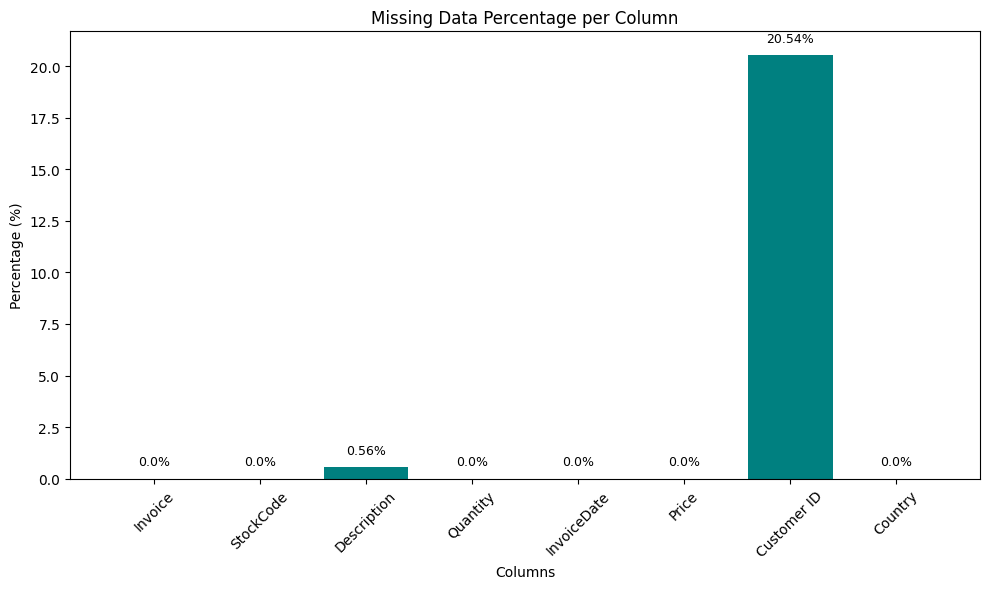

In [5]:


# Calculate missing percentage
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

plt.figure(figsize=(10, 6))  # Increased height to give more space
bars = plt.bar(missing_pct.index, missing_pct.values, color='teal')

plt.title("Missing Data Percentage per Column")
plt.ylabel("Percentage (%)")
plt.xlabel("Columns")
plt.xticks(rotation=45)

#Add percentage labels above each bar
for bar, pct in zip(bars, missing_pct.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{pct}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

#Add top margin to prevent label cutoff
plt.ylim(0,max(missing_pct.values) + 1.15)
plt.subplots_adjust(top=0.9, bottom=0.15)

plt.tight_layout()
plt.show()

Step 4: Handle Missing Values

In [6]:



print("Initial shape:", df.shape)

print("\n=== STEP 2: Missing Values — BEFORE Cleaning ===")
print(df.isnull().sum())

# Remove rows with missing Customer IDs
before = df.shape[0]
df = df.dropna(subset=['Customer ID'])
after = df.shape[0]

print(f"\nRemoved rows missing Customer ID: {before - after}")
print("Shape after Customer ID cleaning:", df.shape)

# Convert InvoiceDate and drop invalid entries
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
invalid_dates = df['InvoiceDate'].isna().sum()

print("\nInvalid InvoiceDate entries:", invalid_dates)

df = df.dropna(subset=['InvoiceDate'])
print("Shape after removing invalid InvoiceDate:", df.shape)

print("\n=== Missing Values — AFTER Cleaning ===")
print(df.isnull().sum())


Initial shape: (525461, 8)

=== STEP 2: Missing Values — BEFORE Cleaning ===
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Removed rows missing Customer ID: 107927
Shape after Customer ID cleaning: (417534, 8)

Invalid InvoiceDate entries: 0
Shape after removing invalid InvoiceDate: (417534, 8)

=== Missing Values — AFTER Cleaning ===
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


Step 3: Data Transformation

Data transformation procedures convert raw transaction logs into consistent formats suitable for feature engineering and machine learning. These include datatype corrections, identifier standardization, behavioural transformation, and return-adjustment operations.

Transformations applied:

Invoice converted to stripped string format to remove whitespace noise.

Customer ID converted to string (categorical identifier).

TransactionValue computed as Quantity × UnitPrice.

Returns (invoices starting with “C”) converted into negative Quantity and negative TransactionValue.

Datetime fields parsed to prepare for temporal feature engineering.

These transformations reflect realistic PFM-equivalent spending signals such as refunds, large purchases, and spending irregularities.

In [7]:
print("\n=== STEP 4: Data Transformation ===")

# Normalize Invoice string formatting
df['Invoice'] = df['Invoice'].astype(str).str.strip()
print("Sample cleaned Invoice values:", df['Invoice'].head().tolist())

# Convert Customer ID to categorical string
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)
print("Sample cleaned Customer IDs:", df['Customer ID'].head().tolist())

# Create TransactionValue
df['TransactionValue'] = df['Quantity'] * df['Price']
print("\nSample TransactionValue calculations:")
print(df[['Quantity', 'Price', 'TransactionValue']].head())

# Mark returns
df['IsReturn'] = df['Invoice'].str.startswith("C")
print("\nReturned transactions:", df['IsReturn'].sum())

# Apply return-based negative transformations
df.loc[df['IsReturn'], 'TransactionValue'] *= -1
df.loc[df['IsReturn'], 'Quantity'] *= -1

print("\nSample rows after return adjustment:")
print(df[['Invoice', 'IsReturn', 'Quantity', 'TransactionValue']].head())



=== STEP 4: Data Transformation ===
Sample cleaned Invoice values: ['489434', '489434', '489434', '489434', '489434']
Sample cleaned Customer IDs: ['13085', '13085', '13085', '13085', '13085']

Sample TransactionValue calculations:
   Quantity  Price  TransactionValue
0        12   6.95              83.4
1        12   6.75              81.0
2        12   6.75              81.0
3        48   2.10             100.8
4        24   1.25              30.0

Returned transactions: 9839

Sample rows after return adjustment:
  Invoice  IsReturn  Quantity  TransactionValue
0  489434     False        12              83.4
1  489434     False        12              81.0
2  489434     False        12              81.0
3  489434     False        48             100.8
4  489434     False        24              30.0


4: Check for Duplicates and Visualize 

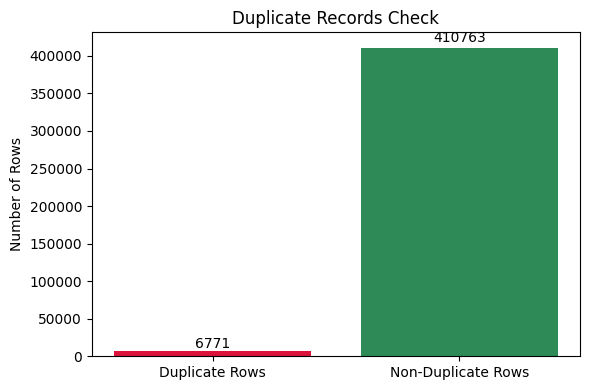

In [8]:
import matplotlib.pyplot as plt

# Compute counts
duplicate_count = df.duplicated().sum()
non_duplicate_count = len(df) - duplicate_count

duplicate_data = {
    'Duplicate Rows': duplicate_count,
    'Non-Duplicate Rows': non_duplicate_count
}

plt.figure(figsize=(6,4))
bars = plt.bar(duplicate_data.keys(), duplicate_data.values(), color=['crimson', 'seagreen'])

plt.title("Duplicate Records Check")
plt.ylabel("Number of Rows")

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + (height * 0.01 if height > 0 else 0.1),
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


3.4.5 Duplicate Removal and Data Quality Verification

Duplicate records, which commonly occur in retail transaction data due to repeated logging or scanning errors, were detected and removed. Removing duplicates is vital because duplicate transactions would otherwise artificially inflate spending counts, distort user behavioural patterns, and bias the CMAB reward estimation (data-cleaning frameworks emphasize duplicate detection as a core step) (Johnson & Liang, 2025).

In [9]:
duplicates = df.duplicated().sum()
print("\n=== STEP 8: Duplicate Check ===")
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)
print("\nDuplicate rows:", df.duplicated().sum())




=== STEP 8: Duplicate Check ===
Duplicate rows: 6771
Shape after removing duplicates: (410763, 10)

Duplicate rows: 0


5: Checking for outliers

In [44]:
df['TransactionValue'] = df['Quantity'] * df['Price']


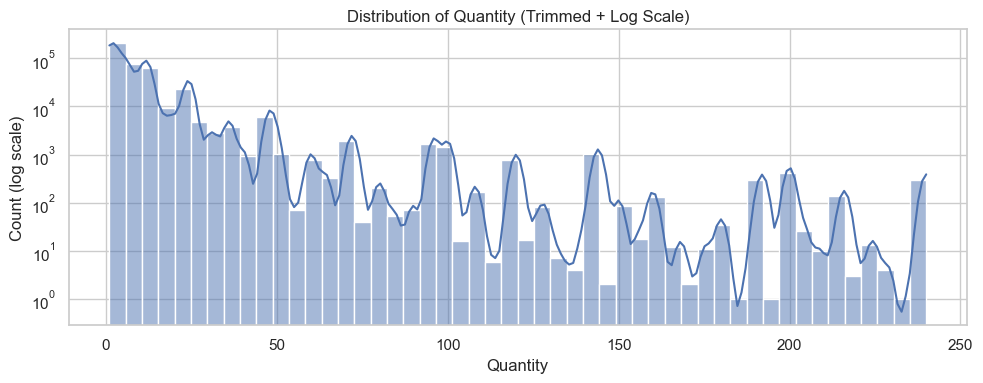

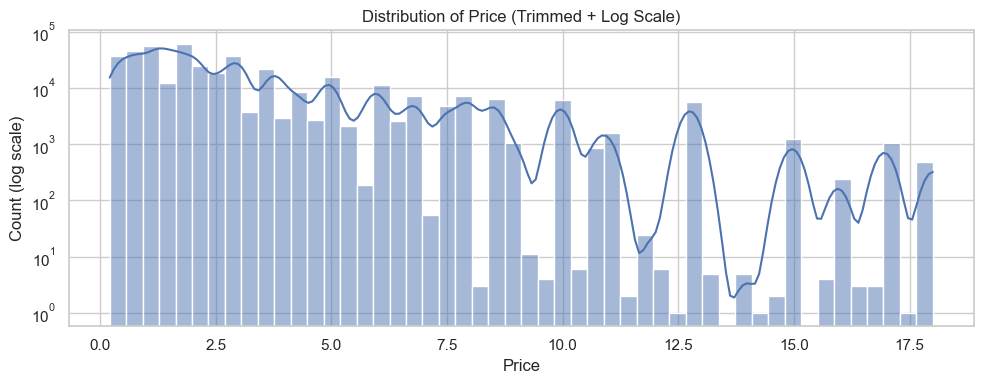

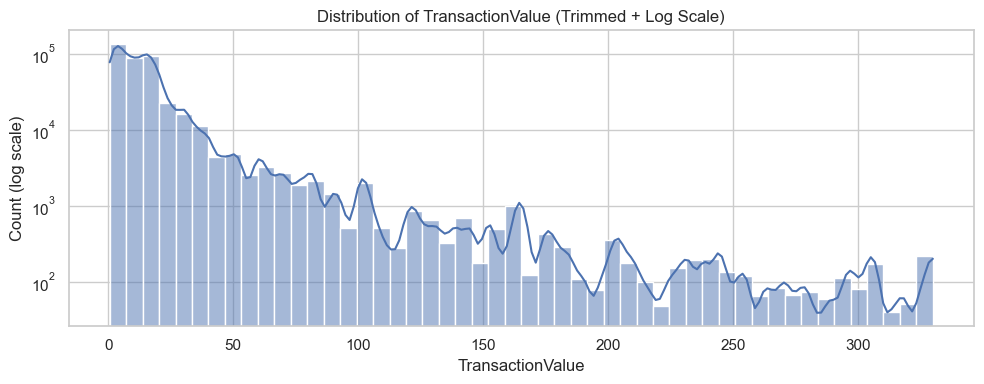

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

def plot_clean_hist(data, column, title, trim_quantile=0.995):
    """
    Plots a clean histogram for skewed retail data.
    - Applies quantile trimming for better visualization (does NOT delete outliers).
    - Uses log scale on Y-axis for readability.
    """
    # Trim only for plotting (keeps data unchanged)
    upper = data[column].quantile(trim_quantile)
    lower = data[column].quantile(1 - trim_quantile)
    trimmed = data[(data[column] >= lower) & (data[column] <= upper)][column]

    plt.figure(figsize=(10,4))
    sns.histplot(trimmed, bins=50, kde=True)
    plt.yscale("log")  # improves visibility for long-tail datasets
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Count (log scale)")
    plt.tight_layout()
    plt.show()

# Plot clean histograms
plot_clean_hist(df, 'Quantity', 'Distribution of Quantity (Trimmed + Log Scale)')
plot_clean_hist(df, 'Price', 'Distribution of Price (Trimmed + Log Scale)')
plot_clean_hist(df, 'TransactionValue', 'Distribution of TransactionValue (Trimmed + Log Scale)')


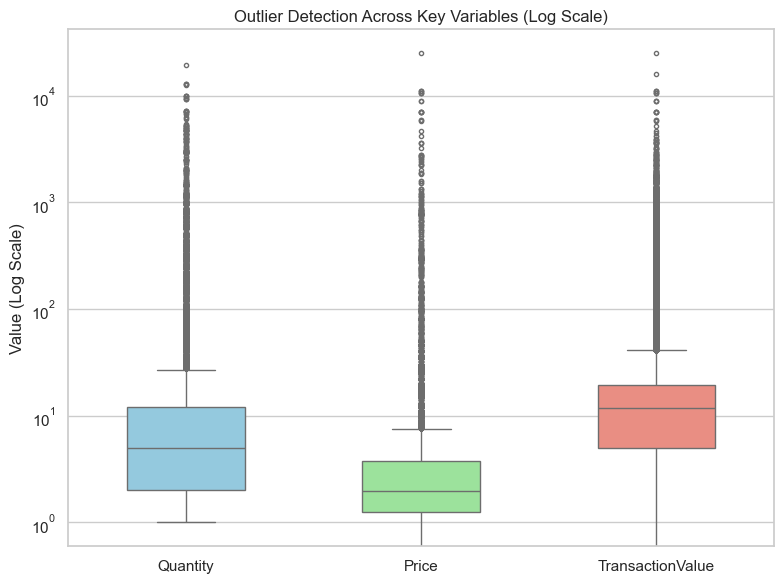

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df[['Quantity', 'Price', 'TransactionValue']],
    palette=['skyblue', 'lightgreen', 'salmon'],
    width=0.5,
    fliersize=3
)
plt.yscale("log")
plt.title("Outlier Detection Across Key Variables (Log Scale)")
plt.ylabel("Value (Log Scale)")
plt.tight_layout()
plt.show()


In [72]:
from scipy import stats
import numpy as np
import pandas as pd

z_scores = np.abs(stats.zscore(df[['Quantity', 'Price', 'TransactionValue']]))

outlier_mask = (z_scores > 3)
outlier_counts = outlier_mask.sum(axis=0)

# Calculate percentages
total_rows = len(df)
outlier_percentages = (outlier_counts / total_rows) * 100

# Create results dataframe
results = pd.DataFrame({
    'Outliers': outlier_counts,
    'Percentage': outlier_percentages.round(2)
}, index=['Quantity', 'Price', 'TransactionValue'])

print("Outliers detected using Z-score > 3:")
print(results)

Outliers detected using Z-score > 3:
                  Outliers  Percentage
Quantity              1345        0.26
Price                  294        0.06
TransactionValue      1388        0.26


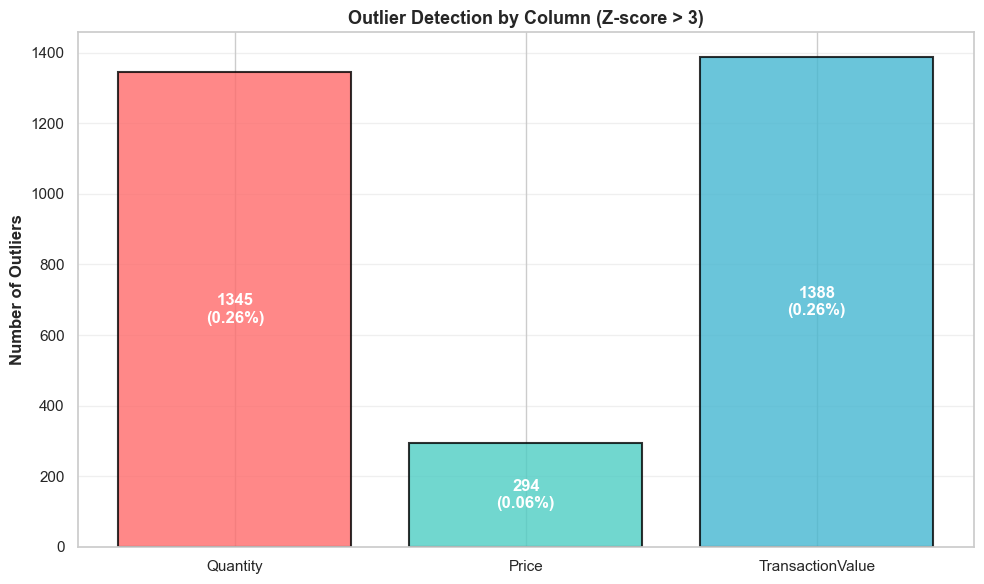


Outliers detected using Z-score > 3:
                  Outliers  Percentage
Quantity              1345        0.26
Price                  294        0.06
TransactionValue      1388        0.26


In [ ]:

z_scores = np.abs(stats.zscore(df[['Quantity', 'Price', 'TransactionValue']]))

outlier_mask = (z_scores > 3)
outlier_counts = outlier_mask.sum(axis=0)

# Calculate percentages
total_rows = len(df)
outlier_percentages = (outlier_counts / total_rows) * 100

# Create results dataframe
results = pd.DataFrame({
    'Outliers': outlier_counts,
    'Percentage': outlier_percentages.round(2)
}, index=['Quantity', 'Price', 'TransactionValue'])

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax.bar(results.index, results['Outliers'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add text inside bars
for i, (bar, count, pct) in enumerate(zip(bars, results['Outliers'], results['Percentage'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height/2,
            f'{int(count)}\n({pct}%)',
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')

ax.set_ylabel('Number of Outliers', fontsize=12, fontweight='bold')
ax.set_title('Outlier Detection by Column (Z-score > 3)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nOutliers detected using Z-score > 3:")
print(results)

In [ ]:
from scipy import stats

print("\n=== STEP 3: Outlier Detection Using Z-scores ===")

df['Z_Quantity'] = np.abs(stats.zscore(df['Quantity']))
df['Z_UnitPrice'] = np.abs(stats.zscore(df['Price']))
df['Z_TransactionValue'] = np.abs(stats.zscore(df['TransactionValue']))

qty_outliers = (df['Z_Quantity'] > 3).sum()
price_outliers = (df['Z_UnitPrice'] > 3).sum()
value_outliers = (df['Z_TransactionValue'] > 3).sum()

print(f"Outliers in Quantity: {qty_outliers}")
print(f"Outliers in UnitPrice: {price_outliers}")
print(f"Outliers in TransactionValue: {value_outliers}")

print("\nOutliers detected but preserved because they represent valid retail behaviour.")



=== STEP 3: Outlier Detection Using Z-scores ===
Outliers in Quantity: 6585
Outliers in UnitPrice: 3309
Outliers in TransactionValue: 11056

✔ Outliers detected but preserved because they represent valid retail behaviour.


In [77]:
df['Invoice'] = df['Invoice'].astype(str).str.strip()
df['Customer ID'] = df['Customer ID'].dropna().astype(int).astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

3.4.6 Save Cleaned Dataset

After all cleaning, transformation, steps, the cleaned dataset is saved as a CSV file. This ensures reproducibility and provides a stable base for subsequent EDA, feature engineering, and CMAB modelling.

In [ ]:
print("\n=== STEP 7: Save Cleaned Dataset ===")
output_path = "../data/interim/cleaned_transactions.csv"
df.to_csv(output_path, index=False)
print("✔ Cleaned dataset saved to:", output_path)


In [13]:



print("Loaded raw dataset:", df.shape)

# ------------------------------
# 1. BASIC CLEANING
# ------------------------------

# Remove rows with missing customer ID (cannot model behaviour)
df = df.dropna(subset=["Customer ID"])

# Convert types
df["Customer ID"] = df["Customer ID"].astype(int).astype(str)
df["Invoice"] = df["Invoice"].astype(str).str.strip()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Replace missing descriptions with placeholder
df["Description"] = df["Description"].fillna("UNKNOWN")

# Remove impossible values
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

print("After base cleaning:", df.shape)

# ------------------------------
# 2. RETURNS HANDLING (CRITICAL)
# ------------------------------

df["IsReturn"] = df["Invoice"].str.startswith("C")

# Convert return rows to negative quantity + revenue
df.loc[df["IsReturn"], "Quantity"] *= -1

# Compute revenue from RAW quantities + raw price
df["TransactionValue"] = df["Quantity"] * df["Price"]

# Validate no return has positive quantities
assert (df.loc[df["IsReturn"], "Quantity"] < 0).all(), "Return quantity error!"
assert (df.loc[df["IsReturn"], "TransactionValue"] < 0).all(), "Return value error!"

print("Returns successfully fixed.")

# ------------------------------
# 3. SAVE CLEAN CLEANED DATASET
# ------------------------------



Loaded raw dataset: (410763, 10)
After base cleaning: (410732, 10)
Returns successfully fixed.


In [14]:


# Load cleaned dataset
print("===== FINAL VERIFICATION REPORT =====\n")

# 1. Missing Value Check
print("1. Missing Values Check:")
print(df.isnull().sum())
print("\n→ All critical fields should show 0 missing values.\n")

# 2. Duplicate Check
print("2. Duplicate Row Check:")
dup_count = df.duplicated().sum()
print(f"Total duplicate rows: {dup_count}")
print("→ Should be 0 after preprocessing.\n")

# 3. Data Types Check
print("3. Data Types:")
print(df.dtypes)
print("\n→ Customer ID should be string, InvoiceDate should be datetime.\n")

# 4. InvoiceDate Validation
print("4. InvoiceDate Parsing Check:")
invalid_dates = df['InvoiceDate'].isna().sum()
print(f"Invalid / unparsable dates: {invalid_dates}")
print("→ Should be 0.\n")

# 5. Return Transaction Validation
print("5. Return (Cancellation) Validation:")

# Check sample where invoice begins with C
return_samples = df[df['Invoice'].str.startswith("C")].head()

print("Sample return transactions:")
print(return_samples[['Invoice', 'Quantity', 'TransactionValue']])

# Ensure they are negative
if (return_samples['Quantity'] < 0).all() and (return_samples['TransactionValue'] < 0).all():
    print("\n✓ Return transformation validated: Quantities and values correctly negative.\n")
else:
    print("\n✗ ERROR: Return transformation incorrect.\n")

# 6. TransactionValue Check
print("6. Transaction Value Calculation Check:")
df['Recalc_Transaction'] = df['Quantity'] * df['Price']

mismatch = (df['Recalc_Transaction'] != df['TransactionValue']).sum()

print(f"Rows with inconsistent transaction value: {mismatch}")
if mismatch == 0:
    print("✓ TransactionValue correctly computed.\n")
else:
    print("✗ ERROR: TransactionValue mismatch found.\n")

df.drop(columns=['Recalc_Transaction'], inplace=True)

# 7. Outlier Detection Verification (Z-score)
print("7. Outlier Detection Summary (Not Removal):")

numeric_fields = ['Quantity', 'Price', 'TransactionValue']

for col in numeric_fields:
    z = np.abs((df[col] - df[col].mean()) / df[col].std())
    outliers = (z > 3).sum()
    print(f"{col}: {outliers} outliers detected (retained).")

print("\n→ Outliers valid for retail behaviour; preserved intentionally.\n")

# 8. Scaling Verification (If Min–Max scaling applied)
scaled_cols = [c for c in df.columns if "_scaled" in c]

if len(scaled_cols) > 0:
    print("8. Scaling Check:")
    print(df[scaled_cols].describe().loc[['min', 'max']])
    print("→ Values should fall within the [0,1] range.\n")
else:
    print("8. Scaling Check: No scaled columns detected — skipping.\n")

# 9. Final Shape Verification
print("9. Final Dataset Shape:")
print(df.shape)
print("→ Ensure this aligns with expected row count after cleaning.\n")

# 10. Sample Preview
print("10. Sample of Cleaned Dataset:")
print(df.head())
print("\n=== STEP 7: Save Cleaned Dataset ===")

output_path = "../data/interim/cleaned_transactions.csv"
df.to_csv(output_path, index=False)
print("✔ Cleaned dataset saved to:", output_path)

print("\n===== VERIFICATION COMPLETE =====")


===== FINAL VERIFICATION REPORT =====

1. Missing Values Check:
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID         0
Country             0
TransactionValue    0
IsReturn            0
dtype: int64

→ All critical fields should show 0 missing values.

2. Duplicate Row Check:
Total duplicate rows: 0
→ Should be 0 after preprocessing.

3. Data Types:
Invoice                     object
StockCode                   object
Description                 object
Quantity                     int64
InvoiceDate         datetime64[ns]
Price                      float64
Customer ID                 object
Country                     object
TransactionValue           float64
IsReturn                      bool
dtype: object

→ Customer ID should be string, InvoiceDate should be datetime.

4. InvoiceDate Parsing Check:
Invalid / unparsable dates: 0
→ Should be 0.

5. Return (Cancellation) Validation:
Sample 